In [11]:
# Imports
import pickle
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
import matplotlib.pyplot as plt
#import plotly.graph_objects as go

(8000, 2) (80, 2)


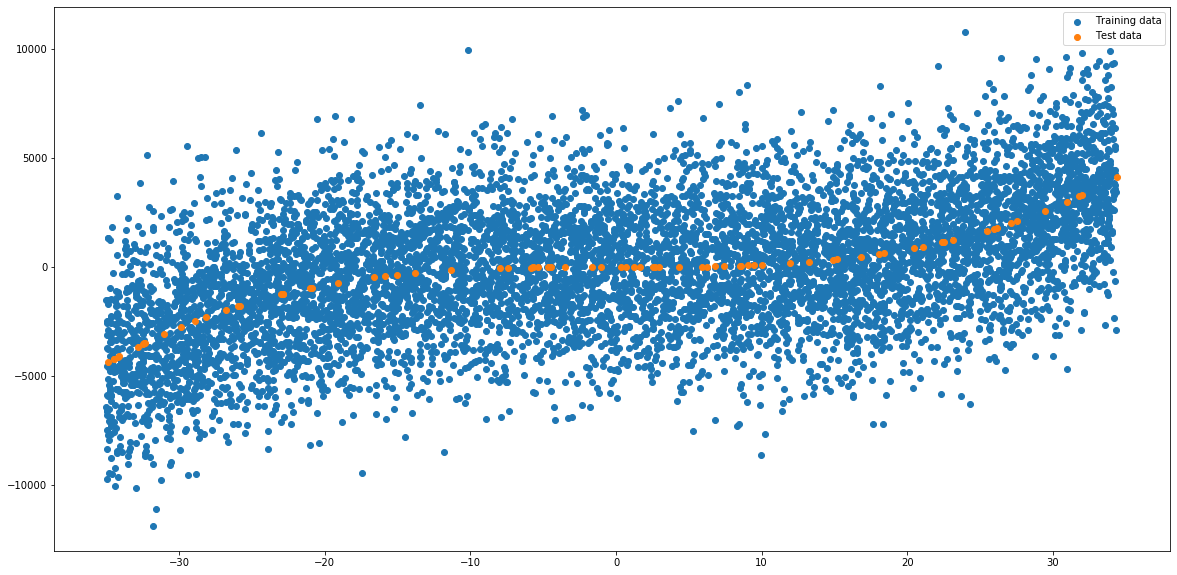

In [12]:
# Reading data from the files
TRAINING_PICKLE_FILE = open('./data/train.pkl', 'rb')
training_temp = pickle.load(TRAINING_PICKLE_FILE)
TESTING_PICKLE_FILE = open('./data/test.pkl', 'rb')
test = pickle.load(TESTING_PICKLE_FILE)
# Checking number of datapoints in train and test and plotting to get rough idea
print(training_temp.shape, test.shape)
plt.figure(figsize=(20,10))
plt.scatter(np.split(training_temp, 2, axis = 1)[0], np.split(training_temp, 2, axis = 1)[1], label="Training data")
plt.scatter(np.split(test, 2, axis = 1)[0], np.split(test, 2, axis = 1)[1], label="Test data")
plt.legend()

In [13]:
# Definitions
MAX_ORDER = 21
MIN_ORDER = 1
NUM_TRAIN_SETS = 10
NUM_DATA_POINTS = training_temp.shape[0]
NUM_DATA_TEST = int(NUM_DATA_POINTS / NUM_TRAIN_SETS)

In [31]:
# Splitting the training dataset and sorting the test data
np.random.shuffle(training_temp)
test = np.sort(test, axis = 0)
# print(test)
training = []
for i in range(NUM_TRAIN_SETS):
    training.append(training_temp[NUM_DATA_TEST*i : NUM_DATA_TEST*(i+1)])
print(training[0])

[[  -19.49292987   951.24296106]
 [  -20.21273083 -5659.30291814]
 [  -29.65885393  2546.16534222]]


In [29]:
# Training the polynomial models
models = [[]]
polies = [[]]
for order in range(MIN_ORDER, MAX_ORDER):
    models.append([])
    polies.append([])
    
    for train_set in range(NUM_TRAIN_SETS):
        poly = PolynomialFeatures(order)
        x_train = np.split(training[train_set], 2, axis = 1)[0]
        x_train = poly.fit_transform(x_train)
        regmodel = LinearRegression().fit(x_train, np.split(training[train_set],2, axis = 1)[1])
        models[order].append(regmodel)
        polies[order].append(poly)
    
# Obtain predictions for each model with the test set
pred = [[]]
for order in range(MIN_ORDER, MAX_ORDER):
    pred.append([])
    for train_set in range(NUM_TRAIN_SETS):
        x_test = np.split(test, 2, axis = 1)[0]
        x_test = polies[order][train_set].transform(x_test)
        pred[order].append(models[order][train_set].predict(x_test))

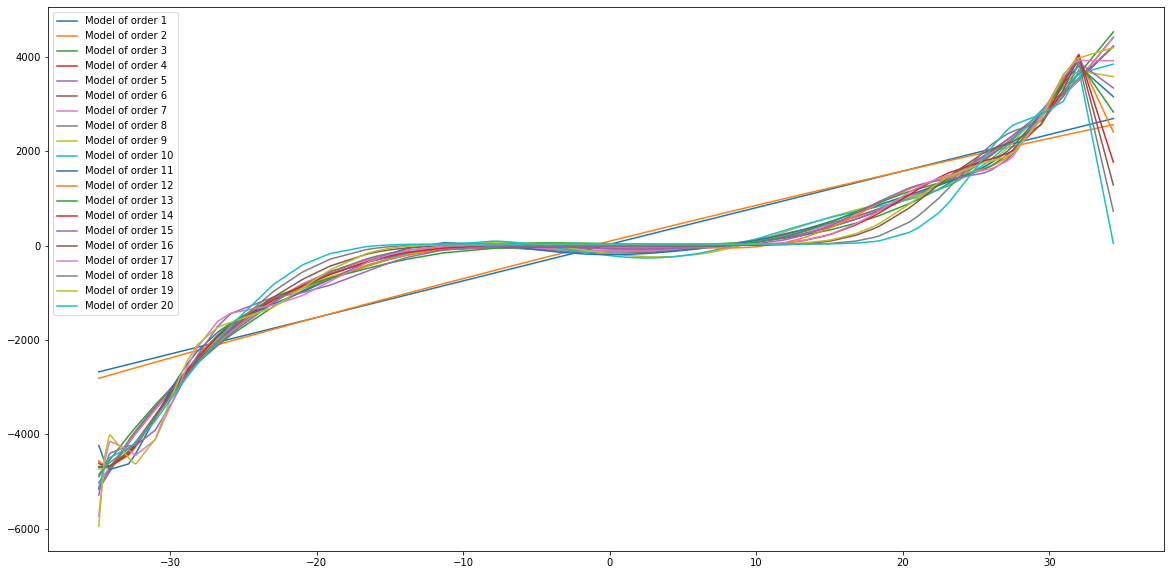

In [38]:
# Plotting one of every polynomial class
plt.figure(figsize=(20,10))
# plt.plot(np.split(test, 2, axis = 1)[0], np.split(test, 2, axis = 1)[1], label='Main', color='black')
for order in range(MIN_ORDER, MAX_ORDER):
    for train_set in range(1):
        plt.plot(np.split(test, 2, axis = 1)[0], pred[order][train_set], label='Model of order '+str(order))
plt.legend()